# Riemannian Flow Matching on the Sphere 🌍

In this notebook we showcase how to train a Riemannian Flow Matching model on the
unit sphere S². We learn to generate samples from a target distribution on the
sphere (a mixture of von Mises-Fisher distributions) using the geodesic flow
matching framework from [Chen & Lipman (2023)](https://arxiv.org/abs/2302.03660).

This notebook can run on any Colab backend.

In [1]:
################################################################################
# Common modules
################################################################################

from etils import ecolab
import jax
import matplotlib.pyplot as plt
import optax
################################################################################
# Datasets
################################################################################

import tqdm

################################################################################
# Hackable diffusion modules
################################################################################

cell_autoreload = True  # @param{type: "boolean"}

with ecolab.adhoc(
    reload=["hackable_diffusion", "kauldron", "lark"],
    invalidate=False,
    cell_autoreload=cell_autoreload,
):
  from hackable_diffusion import hd

In [3]:
diffusion_network_module = hd.diffusion_network
manifolds = hd.manifolds
riemannian = hd.corruption.riemannian
schedules = hd.corruption.schedules
arch_riemannian = hd.architecture.riemannian
conditioning_encoder = hd.architecture.conditioning_encoder
mlp = hd.architecture.mlp
wrappers = hd.inference.wrappers
time_scheduling = hd.sampling.time_scheduling
sampling = hd.sampling.sampling
riemannian_sampling = hd.sampling.riemannian_sampling
time_sampling = hd.training.time_sampling

# Define data distribution on the sphere

In [4]:
import jax
import jax.numpy as jnp


def sample_projected_normal(key, mu, sigma, num_samples):
  """Sample from a Projected Normal distribution on S^2.

  Extremely fast, zero rejection.
  """
  dim = mu.shape[-1]
  z = jax.random.normal(key, (num_samples, dim))
  x = mu + sigma * z
  return x / jnp.linalg.norm(x, axis=-1, keepdims=True)


key = jax.random.PRNGKey(99)
num_samples = 100_000

mu = jnp.array([1.0, 0.0, 0.0])
sigma = 0.15

data = sample_projected_normal(key, mu, sigma, num_samples)

print(f"Sampled {len(data)} points in a fraction of a second.")
print(f"Data shape: {data.shape}")

Sampled 100000 points in a fraction of a second.
Data shape: (100000, 3)


# Visualize training data

In [6]:

import plotly.graph_objects as go
from plotly.subplots import make_subplots
import numpy as np

def plot_sphere_data(fig, points, title='', row=1, col=1, s=3, alpha=0.8):
    """Plot 3D points on the unit sphere using Plotly, with internal layout handling."""
    points = np.asarray(points)

    # 1. Generate the translucent sphere surface
    u = np.linspace(0, 2 * np.pi, 50)
    v = np.linspace(0, np.pi, 50)
    x_surf = np.outer(np.cos(u), np.sin(v))
    y_surf = np.outer(np.sin(u), np.sin(v))
    z_surf = np.outer(np.ones_like(u), np.cos(v))

    # 2. Add the glass sphere to the specific subplot
    fig.add_trace(
        go.Surface(x=x_surf, y=y_surf, z=z_surf,
                   opacity=0.15, colorscale='Greys',
                   showscale=False, hoverinfo='skip'),
        row=row, col=col
    )

    # 3. Add the scatter points to the specific subplot
    fig.add_trace(
        go.Scatter3d(x=points[:, 0], y=points[:, 1], z=points[:, 2],
                     mode='markers',
                     marker=dict(size=s, color=points[:, 2],
                                 colorscale='Viridis', opacity=alpha),
                     name=title,
                     showlegend=False),
        row=row, col=col
    )

    fig.add_trace(
            go.Scatter3d(
                x=[0, 1.2, None, 0, 0, None, 0, 0],
                y=[0, 0, None, 0, 1.2, None, 0, 0],
                z=[0, 0, None, 0, 0, None, 0, 1.2],
                mode='lines',
                line=dict(color='rgba(100, 100, 100, 0.8)', width=3),
                showlegend=False, hoverinfo='skip'
            ), row=row, col=col
        )

    # Add X, Y, Z text labels just at the tips of the lines (1.35 distance)
    fig.add_trace(
        go.Scatter3d(
            x=[1.35, 0, 0],
            y=[0, 1.35, 0],
            z=[0, 0, 1.35],
            mode='text',
            text=['X', 'Y', 'Z'],
            textfont=dict(size=12, color='black'),
            showlegend=False, hoverinfo='skip'
        ), row=row, col=col
    )
    # 4. Handle all layout and scene cleanup internally!
    # update_scenes hits every 3D subplot automatically
    fig.update_scenes(
        xaxis_visible=False,
        yaxis_visible=False,
        zaxis_visible=False
    )

    # Set the global figure margins and size
    fig.update_layout(
        margin=dict(l=0, r=0, b=0, t=40),
        height=600,
        width=1200
    )

    return fig

fig = make_subplots(
    rows=1, cols=1,
    specs=[[{'type': 'scene'}]],
    subplot_titles=("Training data")
)

fig = plot_sphere_data(fig, data, title='Training data')
fig.show()

# Riemannian Flow Matching corruption process

We use the `RiemannianProcess` corruption process with a sphere manifold
and a `LinearRiemannianSchedule`. The schedule uses `alpha(t) = 1 - t`, meaning:
- At `t = 0`, `alpha(0) = 1`, so `xt = geodesic(x0, x1, 1) = x1` (noise).
- At `t = 1`, `alpha(1) = 0`, so `xt = geodesic(x0, x1, 0) = x0` (data).

Sampling therefore runs forward from `t = 0` (noise) to `t = 1` (data).

In [8]:
################################################################################
# Manifold and Schedule
################################################################################

sphere = manifolds.Sphere()
rfm_schedule = schedules.LinearRiemannianSchedule()

################################################################################
# Corruption process
################################################################################

corruption_process = riemannian.RiemannianProcess(
    manifold=sphere,
    schedule=rfm_schedule,
)

# Network definition

We use a simple MLP backbone wrapped in the `RiemannianConditionalBackbone` architecture, which
projects the network output to the tangent space of the sphere at each point.

In [10]:
################################################################################
# Diffusion network definition
################################################################################

# MLP backbone
backbone = mlp.ConditionalMLP(
    hidden_sizes_preprocess=(64, 64),  # Output 3D (ambient dimension of S²)
    hidden_sizes_postprocess=(64, 64),
    activation='gelu',
    zero_init_output=False,
    dropout_rate=0.0,
    conditioning_mechanism='concatenate',
)

# Riemannian flow model wrapper (projects output to tangent space)
flow_model = arch_riemannian.RiemannianConditionalBackbone(
    backbone=backbone,
    manifold=sphere,
)

# Conditioning encoder with sinusoidal time embedding
encoder = conditioning_encoder.ConditioningEncoder(
    time_embedder=conditioning_encoder.SinusoidalTimeEmbedder(
        activation='gelu',
        embedding_dim=64,
        num_features=64,
    ),
    conditioning_embedders={},
    merge_embeddings_fn=conditioning_encoder.SumEmbeddings(),
    conditioning_rules={
        'time': 'concatenate',
    },
)

# The DiffusionNetwork wraps backbone + conditioning encoder
network = diffusion_network_module.DiffusionNetwork(
    backbone_network=flow_model,
    conditioning_encoder=encoder,
    prediction_type='velocity',
)


# Time sampler, optimizer, and loss

In [15]:
################################################################################
# Time sampler
################################################################################

# Sample time uniformly in (0, 1) with small epsilon margin
time_sampler = time_sampling.UniformTimeSampler(
    span=hd.jax_helpers.SafeSpan(safety_epsilon=1e-4),
)

################################################################################
# Optimizer
################################################################################

learning_rate = 1e-3
optimizer = optax.adam(learning_rate)

################################################################################
# Loss function (simple velocity MSE)
################################################################################


def compute_rfm_loss(preds, targets):
  """Mean squared error on velocity predictions."""
  pred_v = preds['velocity']
  target_v = targets['velocity']
  l2 = jnp.sum(jnp.square(pred_v - target_v), axis=-1)
  return jnp.mean(l2)

# Initialize model and train

In [16]:
################################################################################
# Initialize model parameters
################################################################################

key = jax.random.PRNGKey(42)
key, init_key = jax.random.split(key)

# Initialize with dummy inputs
input_shape = (32, 3)  # (batch_size, dim) for S^2
conditioning_shape = (32, 1)

params = network.initialize_variables(
    input_shape=input_shape,
    conditioning_shape={"time": (32, 3)},
    key=init_key,
)["params"]

opt_state = optimizer.init(params)

print("Model initialized!")
print(f"Param count: {sum(p.size for p in jax.tree.leaves(params)):,}")

Model initialized!
Param count: 25,347


In [17]:
################################################################################
# Training loop
################################################################################

batch_size = 256
num_steps = 10_000
log_every = 500


@jax.jit
def train_step(params, opt_state, key, batch_x0):
  """Single training step for Riemannian Flow Matching."""

  key_time, key_noise, key_dropout = jax.random.split(key, 3)

  # Sample noise on the sphere (uniform)
  x1 = sphere.random_uniform(key_noise, batch_x0.shape)

  # Sample time
  time = time_sampler(key_time, x1)

  # Corrupt: compute xt and target velocity along the geodesic
  xt, targets = corruption_process.corrupt(key, batch_x0, time)

  def loss_fn(params):
    preds = network.apply(
        {"params": params},
        time=time,
        xt=xt,
        conditioning=None,
        is_training=True,
        rngs={"dropout": key_dropout},
    )
    return compute_rfm_loss(preds, targets)

  loss, grads = jax.value_and_grad(loss_fn)(params)
  updates, opt_state_new = optimizer.update(grads, opt_state, params)
  params_new = optax.apply_updates(params, updates)
  return params_new, opt_state_new, loss


losses = []
for step in tqdm.tqdm(range(num_steps)):
  key, step_key, data_key = jax.random.split(key, 3)

  # Sample a batch from the dataset
  indices = jax.random.choice(data_key, len(data), (batch_size,))

  batch_x0 = data[indices]

  params, opt_state, loss = train_step(params, opt_state, step_key, batch_x0)

  if step % log_every == 0:
    losses.append(float(loss))
    print(f"Step {step:5d} | Loss: {float(loss):.6f}")

print(f"Final loss: {float(loss):.6f}")

  1%|          | 54/10000 [00:02<04:42, 35.19it/s] 

Step     0 | Loss: 2.826319


  6%|▌         | 596/10000 [00:03<00:19, 472.95it/s]

Step   500 | Loss: 0.555210


 11%|█         | 1082/10000 [00:04<00:16, 524.62it/s]

...

Step  9000 | Loss: 0.388101


 96%|█████████▌| 9587/10000 [00:19<00:00, 562.04it/s]

Step  9500 | Loss: 0.655002


100%|██████████| 10000/10000 [00:20<00:00, 491.38it/s]

Final loss: 0.681496


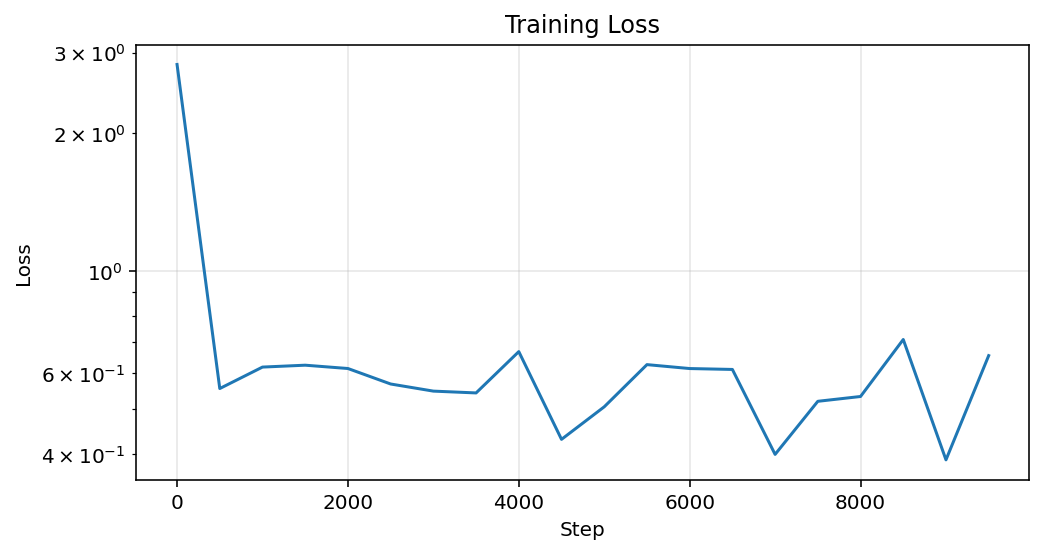

In [18]:
################################################################################
# Plot training loss
################################################################################

plt.figure(figsize=(8, 4))
plt.plot(range(0, num_steps, log_every), losses)
plt.xlabel('Step')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.show()

# Sampling

We sample from the learned model using the `DiffusionSampler` with a
`RiemannianFlowSamplerStep`, which performs Euler integration on the manifold.
We start from uniform noise on the sphere (`t=0`) and integrate to `t=1` (data).

In [19]:
################################################################################
# Set up the sampler
################################################################################

num_sampling_steps = 100

# Riemannian Euler sampler step
stepper = riemannian_sampling.RiemannianFlowSamplerStep(
    corruption_process=corruption_process,
)

# Time schedule: uniform from 0 to 1 (noise to data)
time_schedule = time_scheduling.UniformTimeSchedule()

# Full sampler
sampler = sampling.DiffusionSampler(
    time_schedule=time_schedule,
    stepper=stepper,
    num_steps=num_sampling_steps,
)

# Inference function wraps the trained model
inference_fn = wrappers.FlaxLinenInferenceFn(
    network=network,
    params=params,
)

################################################################################
# Generate samples
################################################################################

num_gen_samples = 2048
key, sample_key = jax.random.split(key)

# Initial noise: uniform on the sphere
initial_noise = sphere.random_uniform(sample_key, (num_gen_samples, 3))

key, sample_key = jax.random.split(key)
final_step, all_steps = sampler(
    inference_fn=inference_fn,
    rng=sample_key,
    initial_noise=initial_noise,
    conditioning=None,
)

generated_samples = final_step.xt
print(f"Generated {generated_samples.shape[0]} samples.")
print(
    "On sphere:"
    f" {jnp.allclose(jnp.linalg.norm(generated_samples, axis=-1), 1.0, atol=1e-3)}"
)

Generated 2048 samples.
On sphere: True


# Compare training data and generated samples

In [20]:
################################################################################
# Side-by-side comparison
################################################################################

fig = make_subplots(
    rows=1, cols=2,
    specs=[[{'type': 'scene'}, {'type': 'scene'}]],
    subplot_titles=("Training data", "Generated samples")
)

fig = plot_sphere_data(fig, data, row=1, col=1)
fig = plot_sphere_data(fig, generated_samples, row=1, col=2)

fig.show()

# Visualize the sampling trajectory

Here we look at the trajectory of a few samples through the denoising process.

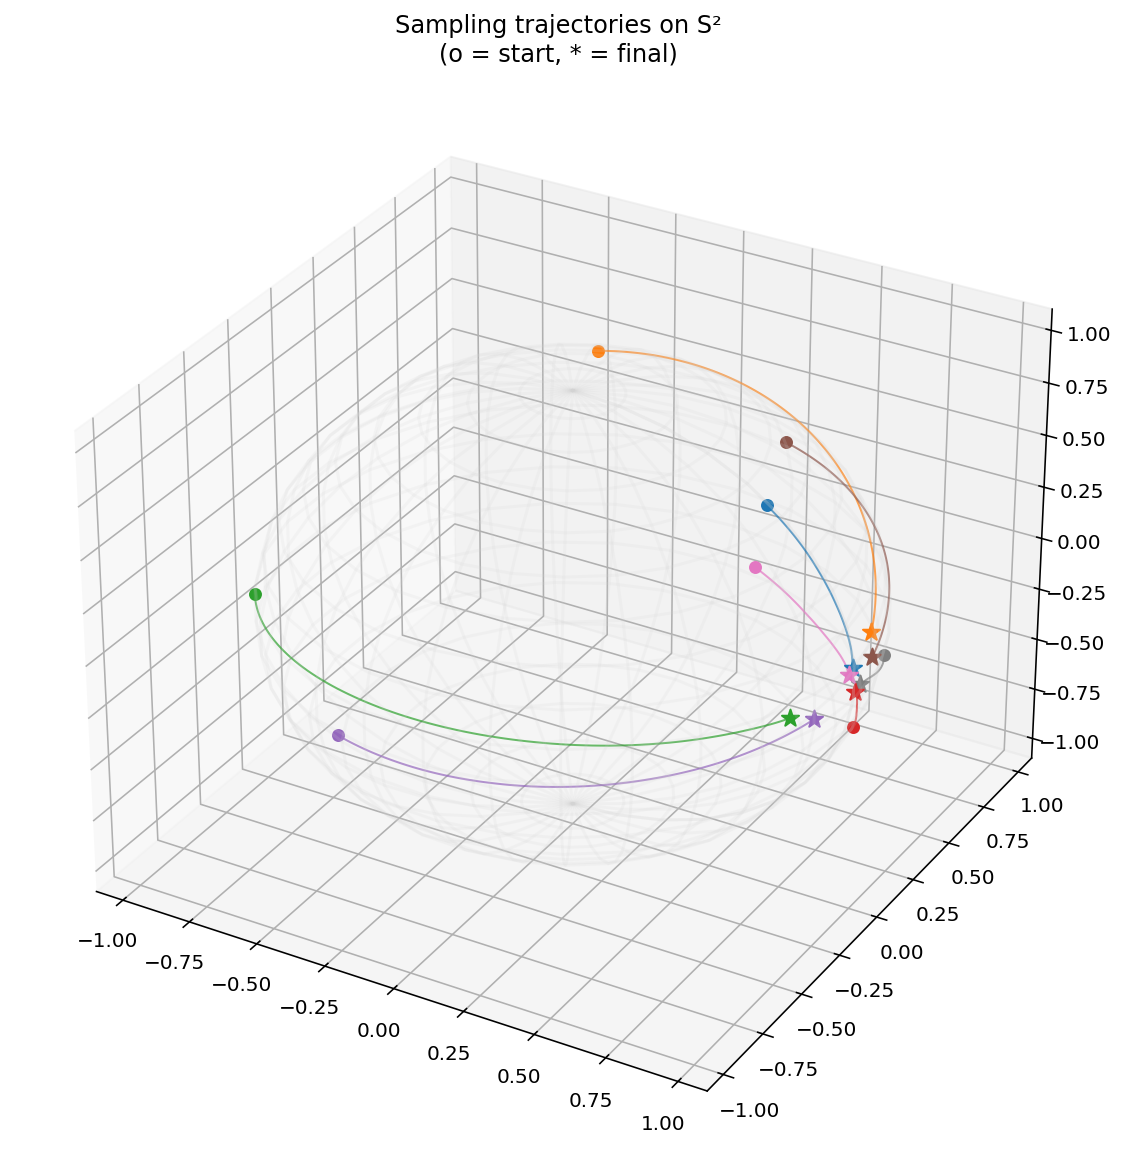

In [21]:
################################################################################
# Trajectory visualization
################################################################################

# Select a few trajectories to visualize
num_trajectories = 8
trajectory_xt = all_steps.xt[
    :, :num_trajectories, :
]  # (num_steps, num_traj, 3)

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

# Draw wireframe sphere
u = jnp.linspace(0, 2 * jnp.pi, 30)
v = jnp.linspace(0, jnp.pi, 20)
x_sphere = jnp.outer(jnp.cos(u), jnp.sin(v))
y_sphere = jnp.outer(jnp.sin(u), jnp.sin(v))
z_sphere = jnp.outer(jnp.ones_like(u), jnp.cos(v))
ax.plot_wireframe(x_sphere, y_sphere, z_sphere, color='lightgray', alpha=0.15)

colors = plt.cm.tab10(range(num_trajectories))
for i in range(num_trajectories):
  traj = trajectory_xt[:, i, :]
  ax.plot(
      traj[:, 0],
      traj[:, 1],
      traj[:, 2],
      '-',
      color=colors[i],
      alpha=0.7,
      linewidth=1,
  )
  ax.scatter(*traj[0], color=colors[i], marker='o', s=30, label=f'start {i}')
  ax.scatter(*traj[-1], color=colors[i], marker='*', s=80)

ax.set_title('Sampling trajectories on S²\n(o = start, * = final)')
ax.set_xlim([-1.1, 1.1])
ax.set_ylim([-1.1, 1.1])
ax.set_zlim([-1.1, 1.1])
plt.show()